# Visualizing Clusters with scikit-learn and Plotly

## Week 8 Practice Program (Program S. No. 16)

**Date:** 03/09/2026

### Problem Statement
Perform Principal Component Analysis (PCA) on the Iris dataset and visualize the first two principal
components using an interactive 2D scatter plot in Plotly.

### Dataset
Built-in Iris dataset from scikit-learn (`sklearn.datasets.load_iris`): 150 samples, 4 numeric features
(sepal length, sepal width, petal length, petal width in cm) and 3 species (setosa, versicolor, virginica).
No external dataset URL is required.

In [1]:
# Step 1: Import the required libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# Plotly renderer: interactive figure inside Jupyter + a static PNG copy of every chart
# (the PNG is what GitHub / PDF previews show, because they cannot run interactive Plotly)
try:
    import kaleido  # noqa: F401  (only needed for the static PNG copies)
    pio.renderers.default = "plotly_mimetype+png"
    pio.renderers["png"].width = 900
    pio.renderers["png"].height = 550
    pio.renderers["png"].scale = 2
except ImportError:
    pio.renderers.default = "plotly_mimetype+notebook"


In [2]:
# Step 2: Load the Iris dataset into a pandas DataFrame
iris = load_iris(as_frame=True)

df = iris.frame.rename(columns={
    "sepal length (cm)": "Sepal Length (cm)",
    "sepal width (cm)": "Sepal Width (cm)",
    "petal length (cm)": "Petal Length (cm)",
    "petal width (cm)": "Petal Width (cm)"
})
df["Species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="target")

feature_columns = ["Sepal Length (cm)", "Sepal Width (cm)", "Petal Length (cm)", "Petal Width (cm)"]

df.head(10)

,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
# Step 3: Basic verification of the dataset
print("Dataset Shape:", df.shape)

print("\nSpecies Counts:")
print(df["Species"].value_counts())

print("\nDescriptive Statistics:")
print(df[feature_columns].describe().round(2))

Dataset Shape: (150, 5)

Species Counts:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Descriptive Statistics:
       Sepal Length (cm)  Sepal Width (cm)  Petal Length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       Petal Width (cm)  
count            150.00  
mean               1.20  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  


In [4]:
# Step 4: Standardize the four features (PCA is sensitive to feature scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_columns])

scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

print("Mean of each standardized feature (should be ~0):")
print(scaled_df.mean().round(3))

print("\nStandard deviation of each standardized feature (should be ~1):")
print(scaled_df.std(ddof=0).round(3))

Mean of each standardized feature (should be ~0):
Sepal Length (cm)   -0.0
Sepal Width (cm)    -0.0
Petal Length (cm)   -0.0
Petal Width (cm)    -0.0
dtype: float64

Standard deviation of each standardized feature (should be ~1):
Sepal Length (cm)    1.0
Sepal Width (cm)     1.0
Petal Length (cm)    1.0
Petal Width (cm)     1.0
dtype: float64


In [5]:
# Step 5: Apply PCA and keep the first two principal components
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
pca_df["Species"] = df["Species"]

# keep the original measurements next to the components (used for hover information)
pca_df = pd.concat([pca_df, df[feature_columns]], axis=1)

pca_df.head(10)

,PC1,PC2,Species,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm)
0,-2.264703,0.480027,setosa,5.1,3.5,1.4,0.2
1,-2.080961,-0.674134,setosa,4.9,3.0,1.4,0.2
2,-2.364229,-0.341908,setosa,4.7,3.2,1.3,0.2
3,-2.299384,-0.597395,setosa,4.6,3.1,1.5,0.2
4,-2.389842,0.646835,setosa,5.0,3.6,1.4,0.2
5,-2.075631,1.489178,setosa,5.4,3.9,1.7,0.4
6,-2.444029,0.047644,setosa,4.6,3.4,1.4,0.3
7,-2.232847,0.223148,setosa,5.0,3.4,1.5,0.2
8,-2.334640,-1.115328,setosa,4.4,2.9,1.4,0.2
9,-2.184328,-0.469014,setosa,4.9,3.1,1.5,0.1


In [6]:
# Step 6: Explained variance and component loadings
explained = pca.explained_variance_ratio_ * 100

print("Explained Variance Ratio:")
print("PC1 :", round(explained[0], 2), "%")
print("PC2 :", round(explained[1], 2), "%")
print("Total variance captured by PC1 + PC2 :", round(explained.sum(), 2), "%")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_columns
)
print("\nComponent Loadings (contribution of each feature):")
print(loadings.round(3))

Explained Variance Ratio:
PC1 : 72.96 %
PC2 : 22.85 %
Total variance captured by PC1 + PC2 : 95.81 %

Component Loadings (contribution of each feature):
                     PC1    PC2
Sepal Length (cm)  0.521  0.377
Sepal Width (cm)  -0.269  0.923
Petal Length (cm)  0.580  0.024
Petal Width (cm)   0.565  0.067


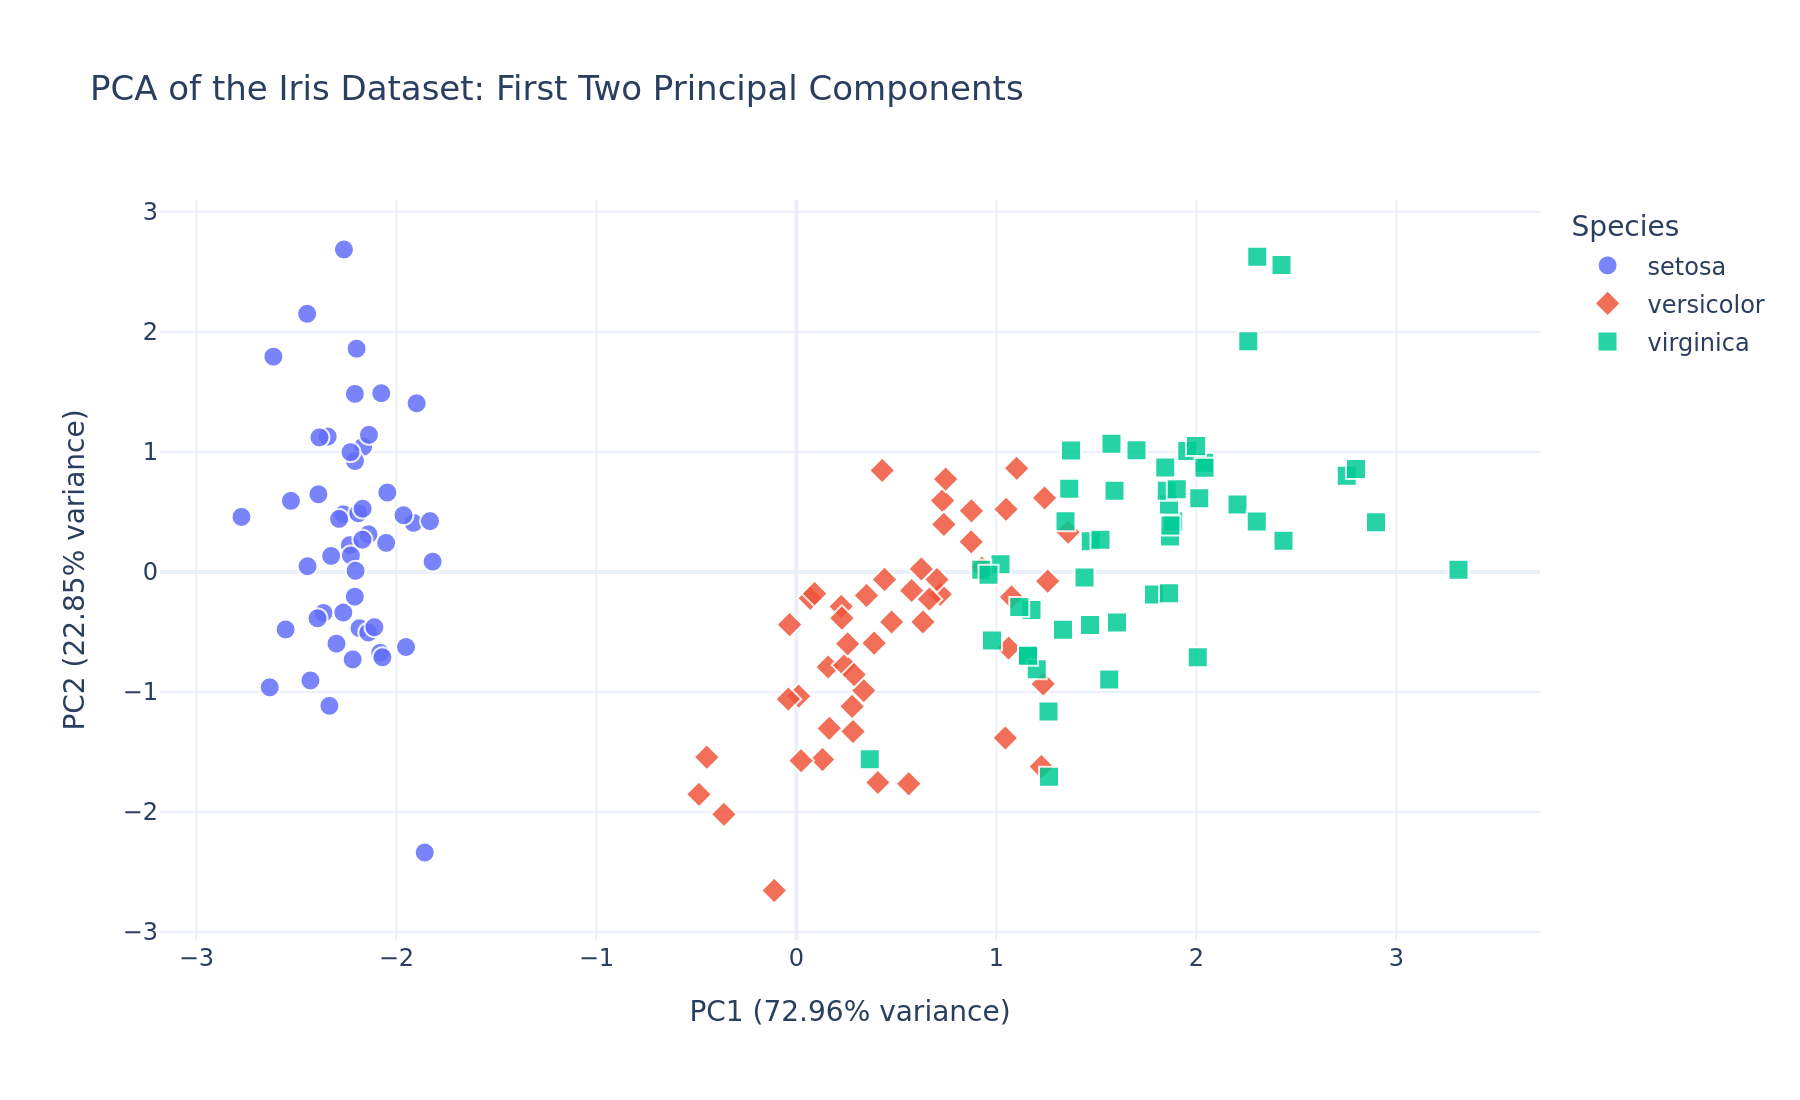

In [7]:
# Step 7: Interactive 2D scatter plot of PC1 vs PC2 coloured by species
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Species",
    symbol="Species",
    hover_data={
        "PC1": ":.3f",
        "PC2": ":.3f",
        "Sepal Length (cm)": True,
        "Sepal Width (cm)": True,
        "Petal Length (cm)": True,
        "Petal Width (cm)": True
    },
    title="PCA of the Iris Dataset: First Two Principal Components",
    labels={
        "PC1": f"PC1 ({explained[0]:.2f}% variance)",
        "PC2": f"PC2 ({explained[1]:.2f}% variance)"
    }
)

fig.update_traces(marker=dict(size=10, opacity=0.85, line=dict(width=1, color="white")))

fig.update_layout(
    legend_title_text="Species",
    width=900,
    height=550,
    template="plotly_white"
)

fig.show()

  Principal Component  Explained Variance (%)  Cumulative Variance (%)
0                 PC1                   72.96                    72.96
1                 PC2                   22.85                    95.81
2                 PC3                    3.67                    99.48
3                 PC4                    0.52                   100.00


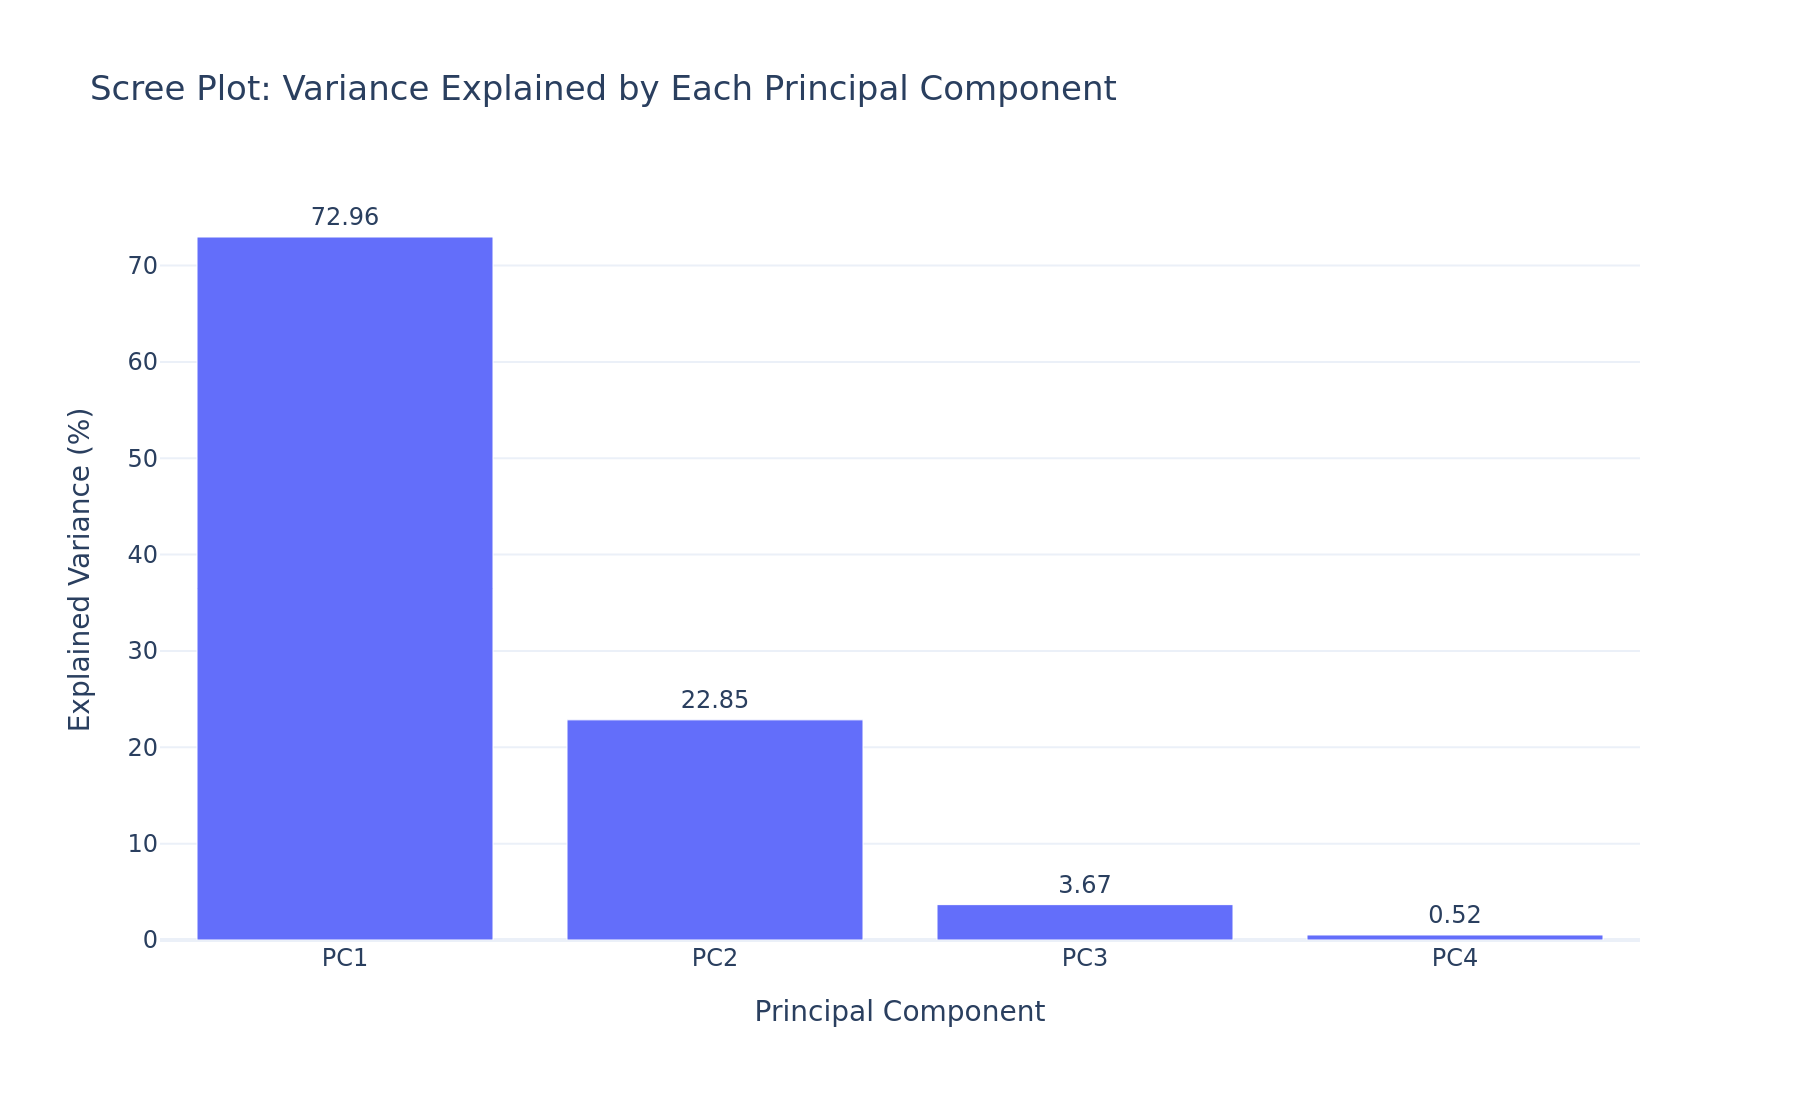

In [8]:
# Step 8: Scree plot - variance explained by every component (supporting chart)
pca_full = PCA(n_components=4, random_state=42).fit(X_scaled)

scree_df = pd.DataFrame({
    "Principal Component": ["PC1", "PC2", "PC3", "PC4"],
    "Explained Variance (%)": (pca_full.explained_variance_ratio_ * 100).round(2)
})
scree_df["Cumulative Variance (%)"] = scree_df["Explained Variance (%)"].cumsum().round(2)

print(scree_df)

fig_scree = px.bar(
    scree_df,
    x="Principal Component",
    y="Explained Variance (%)",
    text="Explained Variance (%)",
    title="Scree Plot: Variance Explained by Each Principal Component"
)
fig_scree.update_traces(textposition="outside")
fig_scree.update_layout(width=900, height=550, template="plotly_white")

fig_scree.show()

In [9]:
# Step 9: Analyse the clusters in the principal-component space
centroids = pca_df.groupby("Species")[["PC1", "PC2"]].mean().round(3)
print("Centroid of each species in PC space:")
print(centroids)

spread = pca_df.groupby("Species")[["PC1", "PC2"]].std().round(3)
print("\nSpread (standard deviation) of each species in PC space:")
print(spread)

Centroid of each species in PC space:
              PC1    PC2
Species                 
setosa     -2.225  0.289
versicolor  0.496 -0.550
virginica   1.728  0.261

Spread (standard deviation) of each species in PC space:
              PC1    PC2
Species                 
setosa      0.206  0.934
versicolor  0.464  0.833
virginica   0.571  0.876


In [10]:
# Step 10: Save the interactive chart, a static image and the PCA dataset
fig.write_html("program16_pca_scatter.html")
print("Interactive PCA scatter plot saved as program16_pca_scatter.html")

try:
    fig.write_image("program16_pca_scatter.png", width=900, height=550, scale=2)
    fig_scree.write_image("program16_scree_plot.png", width=900, height=550, scale=2)
    print("Static images saved as program16_pca_scatter.png and program16_scree_plot.png")
except Exception as error:
    print("Static image not saved (kaleido not available):", error)

pca_df.to_csv("program16_iris_pca.csv", index=False)
print("PCA dataset saved as program16_iris_pca.csv")

Interactive PCA scatter plot saved as program16_pca_scatter.html


Static images saved as program16_pca_scatter.png and program16_scree_plot.png
PCA dataset saved as program16_iris_pca.csv


In [11]:
# Step 11: Summary of the analysis
print("PCA ANALYSIS SUMMARY")
print("-" * 45)
print("Total samples              :", len(pca_df))
print("Original features          :", len(feature_columns))
print("Components retained        : 2")
print("Variance explained by PC1  :", round(explained[0], 2), "%")
print("Variance explained by PC2  :", round(explained[1], 2), "%")
print("Total variance retained    :", round(explained.sum(), 2), "%")
print("Most influential feature   :", loadings["PC1"].abs().idxmax(), "(on PC1)")
print("Well separated species     : setosa")
print("Partially overlapping      : versicolor and virginica")

PCA ANALYSIS SUMMARY
---------------------------------------------
Total samples              : 150
Original features          : 4
Components retained        : 2
Variance explained by PC1  : 72.96 %
Variance explained by PC2  : 22.85 %
Total variance retained    : 95.81 %
Most influential feature   : Petal Length (cm) (on PC1)
Well separated species     : setosa
Partially overlapping      : versicolor and virginica
